# 02 - Analyse Exploratoire des Données (EDA)

## Objectifs
- Analyse univariée : distribution de chaque variable
- Analyse bivariée : relations entre variables et la survie
- Analyse multivariée : interactions complexes
- Corrélations
- **Insights** pour guider la modélisation

In [131]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Couleurs personnalisées
COLORS = {'died': '#ff6b6b', 'survived': '#6bcb77'}

In [132]:
# Charger les données
df = pd.read_csv('../data/raw/train.csv')
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Dataset chargé : 891 lignes, 12 colonnes


---
## 1. Analyse Univariée

Étudier la distribution de chaque variable individuellement.

### 1.1 Variable cible : Survived

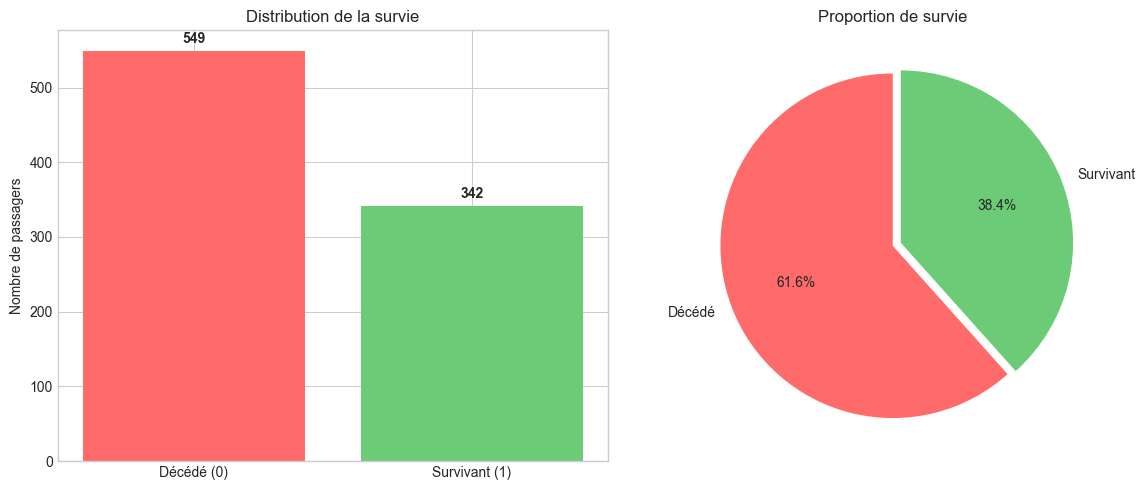


Taux de survie : 38.4%
- Dataset légèrement déséquilibré


In [133]:
# Distribution de la survie
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
survived_counts = df['Survived'].value_counts()
colors = [COLORS['died'], COLORS['survived']]
axes[0].bar(['Décédé (0)', 'Survivant (1)'], survived_counts.values, color=colors)
axes[0].set_ylabel('Nombre de passagers')
axes[0].set_title('Distribution de la survie')
for i, v in enumerate(survived_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(survived_counts.values, labels=['Décédé', 'Survivant'], 
            autopct='%1.1f%%', colors=colors, startangle=90, explode=[0, 0.05])
axes[1].set_title('Proportion de survie')

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=150)
plt.show()

print(f"\nTaux de survie : {df['Survived'].mean()*100:.1f}%")
print("- Dataset légèrement déséquilibré")

### 1.2 Variables numériques

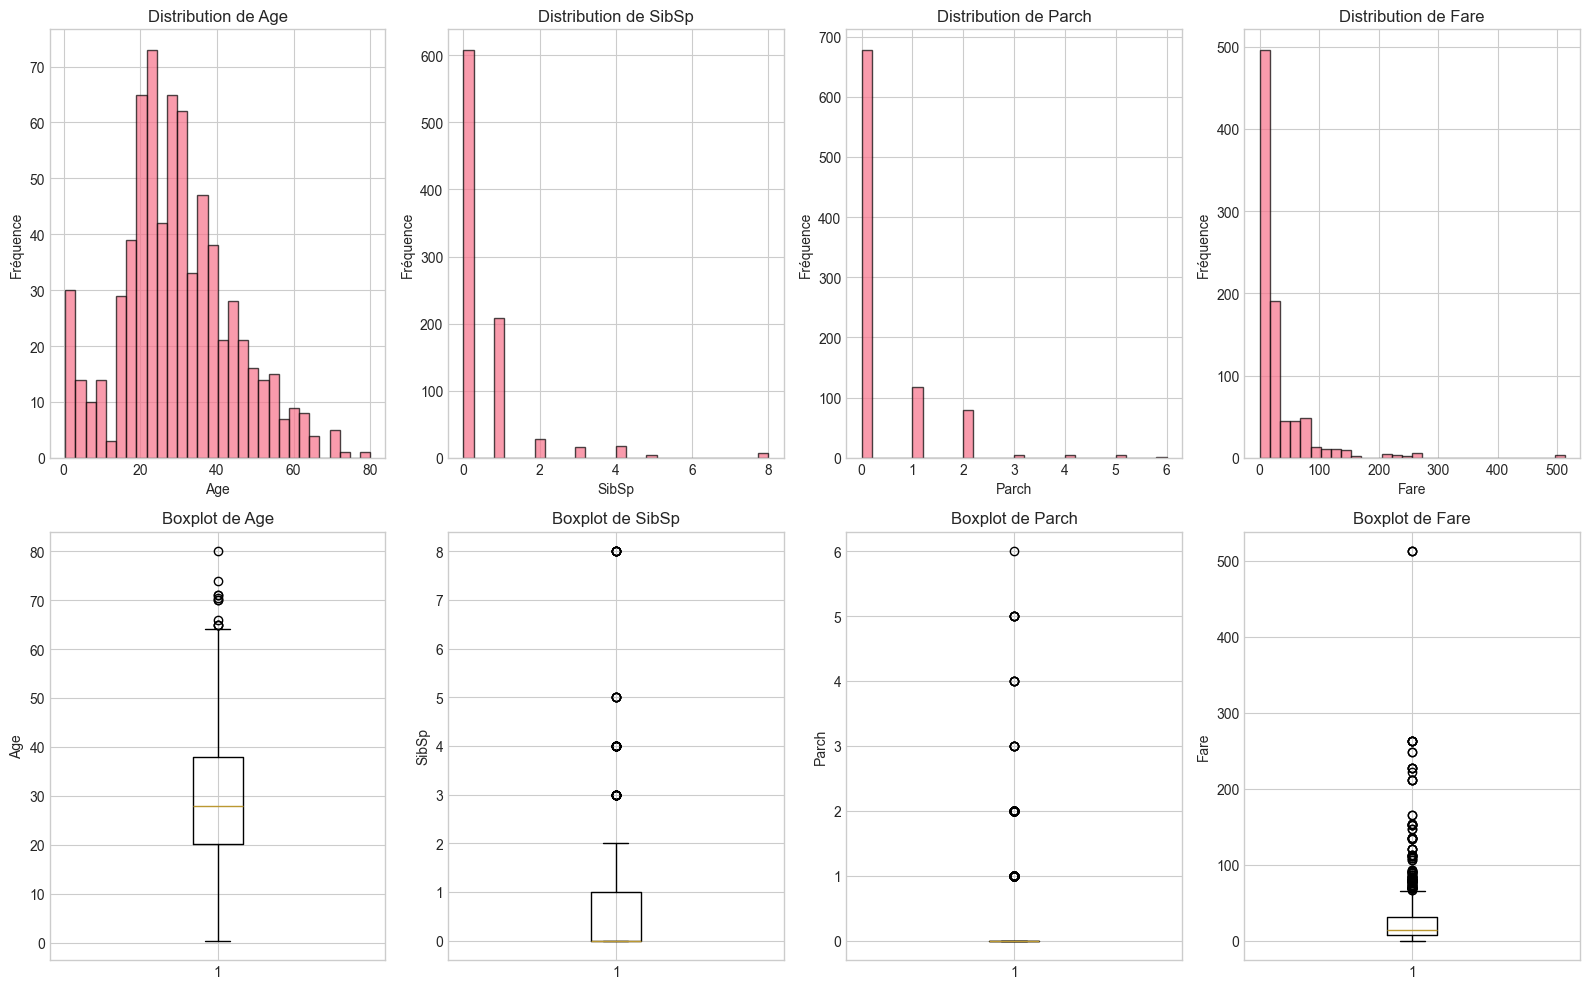

In [134]:
# Distribution des variables numériques
numerical_cols = ['Age', 'SibSp', 'Parch', 'Fare']

# Créer les figures
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

for i, col in enumerate(numerical_cols):
    # Histogramme
    axes[0, i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Fréquence')
    axes[0, i].set_title(f'Distribution de {col}')
    
    # Boxplot
    axes[1, i].boxplot(df[col].dropna())
    axes[1, i].set_ylabel(col)
    axes[1, i].set_title(f'Boxplot de {col}')

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/numerical_distributions.png', dpi=150)
plt.show()

In [135]:
# Statistiques détaillées
print("Statistiques des variables numériques :")
print("="*60)

# Calcul des statistiques pour chaque variable numérique
for col in numerical_cols:
    data = df[col].dropna()
    print(f"\n{col}:")
    print(f"  Moyenne: {data.mean():.2f}")
    print(f"  Médiane: {data.median():.2f}")
    print(f"  Écart-type: {data.std():.2f}")
    print(f"  Min/Max: {data.min():.2f} / {data.max():.2f}")
    print(f"  Skewness: {data.skew():.2f}")
    print(f"  Kurtosis: {data.kurtosis():.2f}")

Statistiques des variables numériques :

Age:
  Moyenne: 29.70
  Médiane: 28.00
  Écart-type: 14.53
  Min/Max: 0.42 / 80.00
  Skewness: 0.39
  Kurtosis: 0.18

SibSp:
  Moyenne: 0.52
  Médiane: 0.00
  Écart-type: 1.10
  Min/Max: 0.00 / 8.00
  Skewness: 3.70
  Kurtosis: 17.88

Parch:
  Moyenne: 0.38
  Médiane: 0.00
  Écart-type: 0.81
  Min/Max: 0.00 / 6.00
  Skewness: 2.75
  Kurtosis: 9.78

Fare:
  Moyenne: 32.20
  Médiane: 14.45
  Écart-type: 49.69
  Min/Max: 0.00 / 512.33
  Skewness: 4.79
  Kurtosis: 33.40


**Observations :**
- **Age** : Distribution relativement normale, pic vers 20-30 ans
- **SibSp** : Majorité à 0, distribution très asymétrique
- **Parch** : Similaire à SibSp, majorité voyageant seul
- **Fare** : Très asymétrique avec outliers importants (billets de luxe)

### 1.3 Variables catégorielles

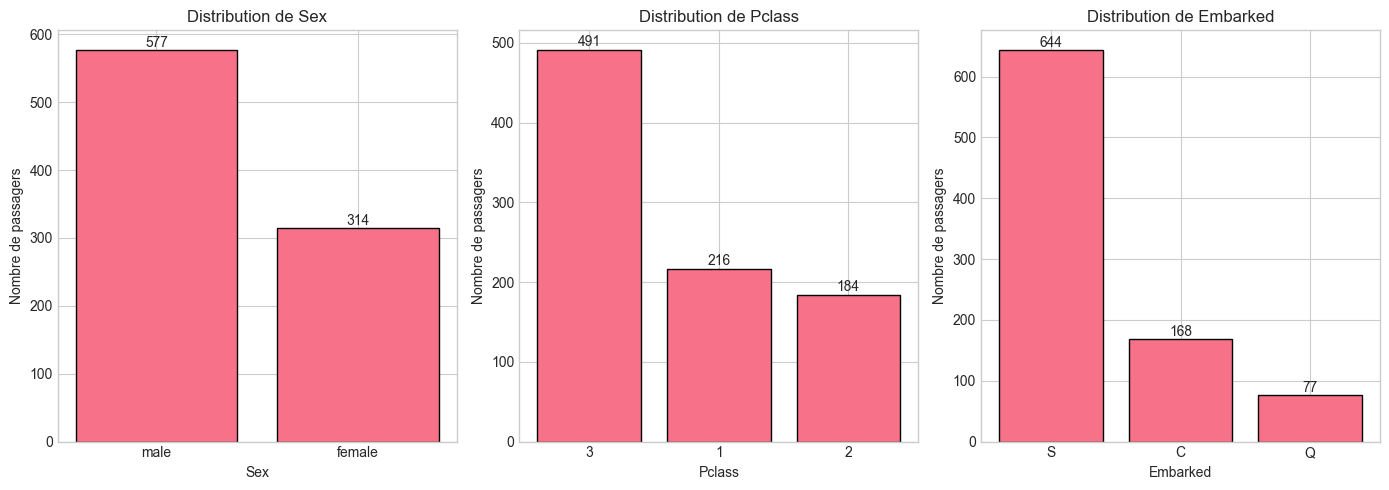

In [136]:
# Distribution des variables catégorielles
categorical_cols = ['Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, edgecolor='black')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre de passagers')
    axes[i].set_title(f'Distribution de {col}')
    
    # Ajouter les valeurs
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha='center')

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/categorical_distributions.png', dpi=150)
plt.show()

**Observations :**
- **Sex** : Plus d'hommes (577) que de femmes (314)
- **Pclass** : Majorité en 3ème classe (491), moins en 1ère (216)
- **Embarked** : Southampton (S) est le port principal

---
## 2. Analyse Bivariée : Relations avec la survie

### 2.1 Survie par Sexe

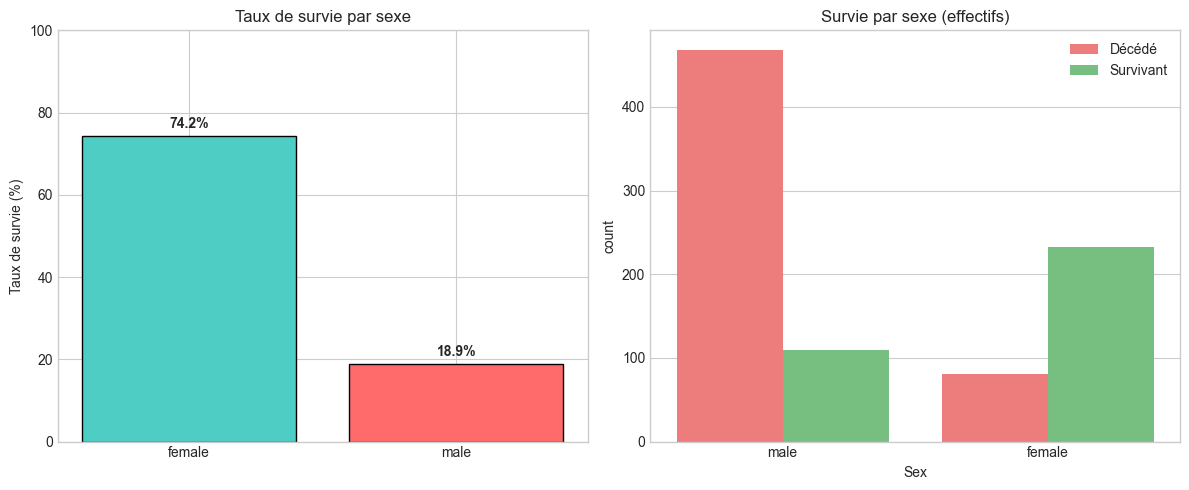

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Taux de survie par sexe
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
colors = ['#4ecdc4', '#ff6b6b']
axes[0].bar(survival_by_sex.index, survival_by_sex.values, color=colors, edgecolor='black')
axes[0].set_ylabel('Taux de survie (%)')
axes[0].set_title('Taux de survie par sexe')
axes[0].set_ylim(0, 100)
for i, v in enumerate(survival_by_sex.values):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Taux de survie par sexe (effectifs)
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[1], palette=[COLORS['died'], COLORS['survived']])
axes[1].set_title('Survie par sexe (effectifs)')
axes[1].legend(['Décédé', 'Survivant'])

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/survival_by_sex.png', dpi=150)
plt.show()

**INSIGHT  :** Les femmes ont un taux de survie de **74%** contre seulement **19%** pour les hommes. Le principe "Les femmes et les enfants d'abord" semble avoir été appliqué.

### 2.2 Survie par Classe

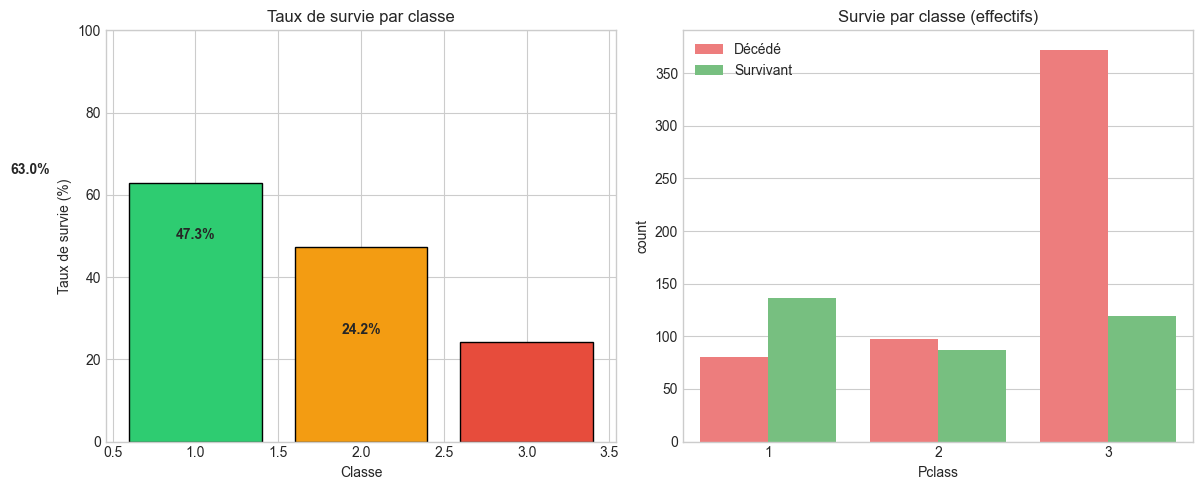

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Taux de survie par classe
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(survival_by_class.index, survival_by_class.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Taux de survie (%)')
axes[0].set_title('Taux de survie par classe')
axes[0].set_ylim(0, 100)
for i, v in enumerate(survival_by_class.values):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Count plot
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[1], palette=[COLORS['died'], COLORS['survived']])
axes[1].set_title('Survie par classe (effectifs)')
axes[1].legend(['Décédé', 'Survivant'])

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/survival_by_class.png', dpi=150)
plt.show()

**INSIGHT :** La 1ère classe a un taux de survie de **63%**, la 2ème **47%**, et la 3ème seulement **24%**. La position sociale a clairement influencé les chances de survie.

### 2.3 Survie par Âge

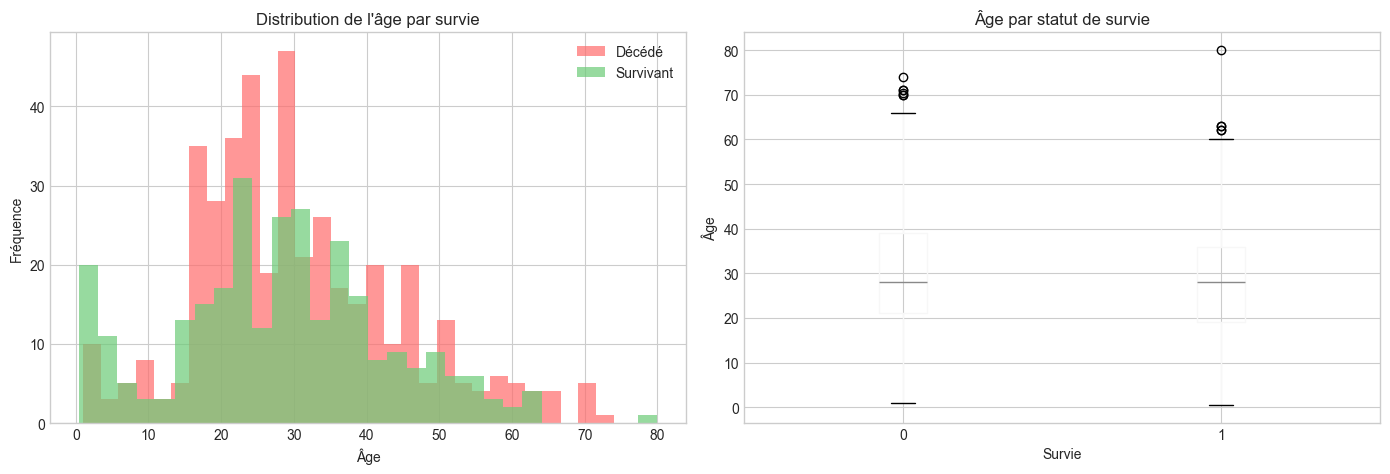

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de l'âge par survie
df[df['Survived'] == 0]['Age'].hist(ax=axes[0], bins=30, alpha=0.7, 
                                     label='Décédé', color=COLORS['died'])
df[df['Survived'] == 1]['Age'].hist(ax=axes[0], bins=30, alpha=0.7, 
                                     label='Survivant', color=COLORS['survived'])
axes[0].set_xlabel('Âge')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de l\'âge par survie')
axes[0].legend()

# Boxplot de l'âge par survie
df.boxplot(column='Age', by='Survived', ax=axes[1])
axes[1].set_xlabel('Survie')
axes[1].set_ylabel('Âge')
axes[1].set_title('Âge par statut de survie')
plt.suptitle('')

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/survival_by_age.png', dpi=150)
plt.show()

C:\Users\besse\AppData\Local\Temp\ipykernel_28120\3950631057.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df.groupby('AgeGroup')['Survived'].agg(['mean', 'count'])


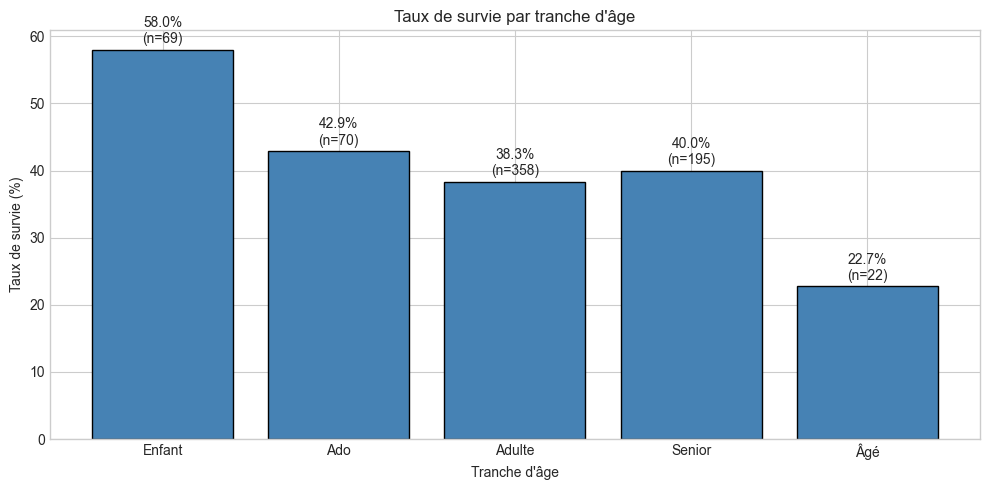

In [140]:
# Créer des tranches d'âge
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                        labels=['Enfant', 'Ado', 'Adulte', 'Senior', 'Âgé'])

survival_by_age = df.groupby('AgeGroup')['Survived'].agg(['mean', 'count'])
survival_by_age['mean'] = survival_by_age['mean'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(survival_by_age.index.astype(str), survival_by_age['mean'], 
              edgecolor='black', color='steelblue')
ax.set_xlabel('Tranche d\'âge')
ax.set_ylabel('Taux de survie (%)')
ax.set_title('Taux de survie par tranche d\'âge')

for bar, (idx, row) in zip(bars, survival_by_age.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{row["mean"]:.1f}%\n(n={int(row["count"])})', ha='center')

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/survival_by_age_group.png', dpi=150)
plt.show()

# Supprimer la colonne temporaire
df.drop('AgeGroup', axis=1, inplace=True)

**INSIGHT :** Les enfants (< 12 ans) ont le meilleur taux de survie (~58%). "Les femmes et les enfants d'abord" se confirme.

### 2.4 Survie par Port d'embarquement

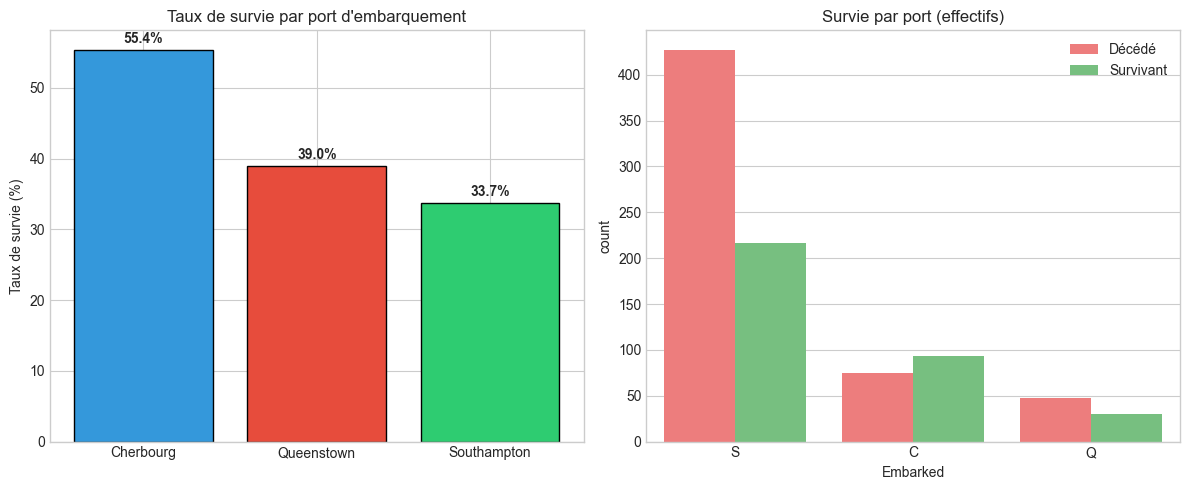

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Taux de survie par port
survival_by_embarked = df.groupby('Embarked')['Survived'].mean() * 100
port_names = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
survival_by_embarked.index = survival_by_embarked.index.map(port_names)

axes[0].bar(survival_by_embarked.index, survival_by_embarked.values, 
            color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_ylabel('Taux de survie (%)')
axes[0].set_title('Taux de survie par port d\'embarquement')
for i, v in enumerate(survival_by_embarked.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Count plot
sns.countplot(data=df, x='Embarked', hue='Survived', ax=axes[1], 
              palette=[COLORS['died'], COLORS['survived']])
axes[1].set_title('Survie par port (effectifs)')
axes[1].legend(['Décédé', 'Survivant'])

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/survival_by_embarked.png', dpi=150)
plt.show()

**INSIGHT :** Cherbourg (C) a le meilleur taux de survie (~55%). Probablement lié à la classe sociale des passagers embarquant à ce port.

---
## 3. Analyse Multivariée

### 3.1 Sexe + Classe

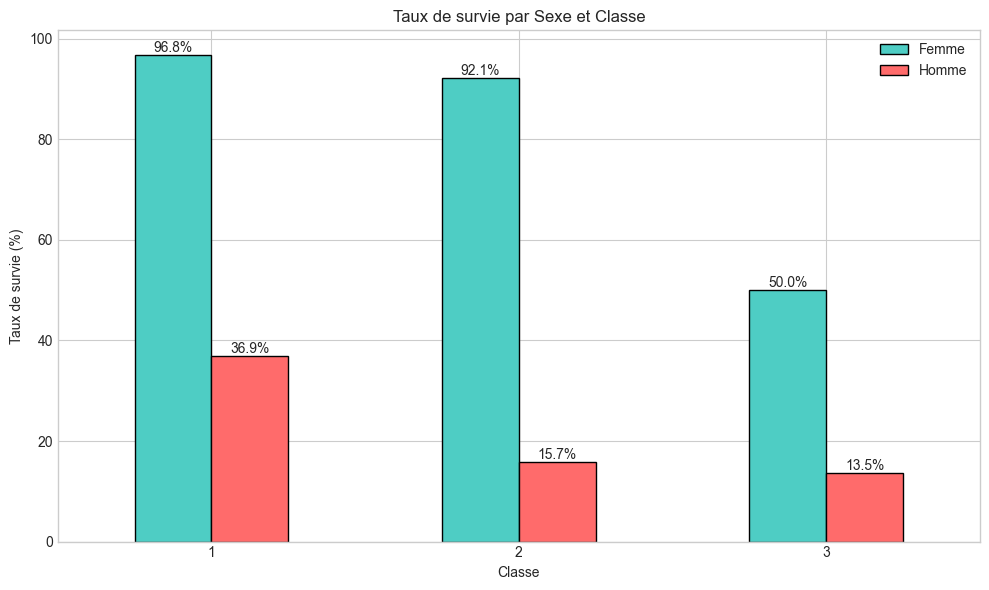

Sex     female  male
Pclass              
1         96.8  36.9
2         92.1  15.7
3         50.0  13.5


In [142]:
# Tableau croisé
survival_sex_class = df.pivot_table(values='Survived', index='Pclass', 
                                     columns='Sex', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(10, 6))
survival_sex_class.plot(kind='bar', ax=ax, color=['#4ecdc4', '#ff6b6b'], edgecolor='black')
ax.set_xlabel('Classe')
ax.set_ylabel('Taux de survie (%)')
ax.set_title('Taux de survie par Sexe et Classe')
ax.legend(['Femme', 'Homme'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Ajouter les valeurs
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.savefig('../reports/figures/survival_sex_class.png', dpi=150)
plt.show()

print(survival_sex_class.round(1))

**INSIGHT :** 
- Les femmes de 1ère et 2ème classe ont survécu à **~97%** et **92%**
- Les hommes de 3ème classe n'ont survécu qu'à **14%**
- Le sexe ET la classe sont des facteurs critiques

### 3.2 Taille de la famille

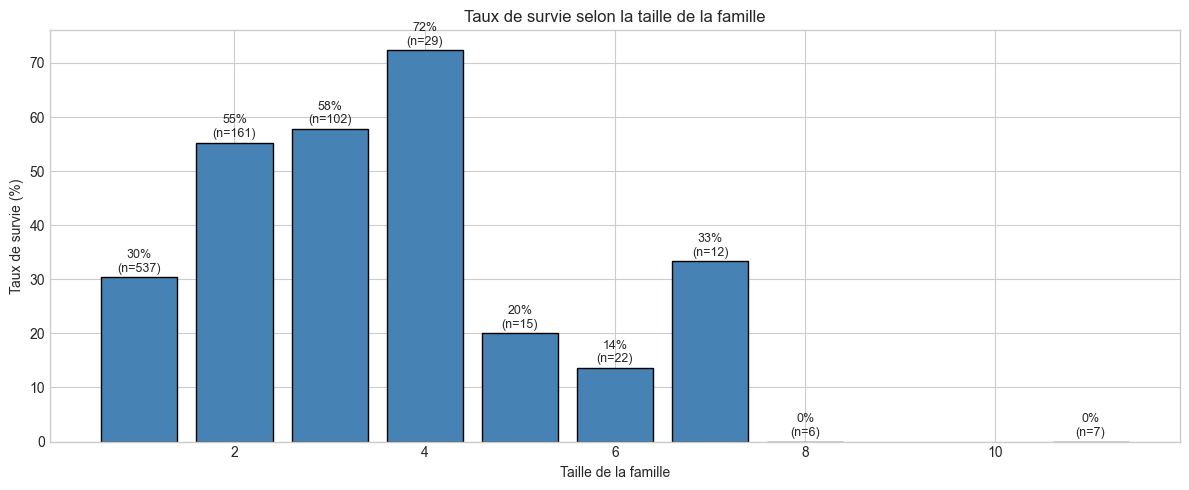

In [143]:
# Créer une variable "Taille de famille"
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Analyser la survie par taille de famille
survival_by_family = df.groupby('FamilySize')['Survived'].agg(['mean', 'count'])
survival_by_family['mean'] = survival_by_family['mean'] * 100

# Créer le graphique
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(survival_by_family.index, survival_by_family['mean'], 
              edgecolor='black', color='steelblue')
ax.set_xlabel('Taille de la famille')
ax.set_ylabel('Taux de survie (%)')
ax.set_title('Taux de survie selon la taille de la famille')

# Ajouter les valeurs au-dessus des barres
for bar, (idx, row) in zip(bars, survival_by_family.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{row["mean"]:.0f}%\n(n={int(row["count"])})', ha='center', fontsize=9)

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/survival_by_family_size.png', dpi=150)
plt.show()

# Supprimer la colonne temporaire
df.drop('FamilySize', axis=1, inplace=True)

**INSIGHT :** Les familles de taille moyenne (2-4 personnes) ont les meilleurs taux de survie. Voyager seul ou en très grande famille réduit les chances.

---
## 4. Analyse des corrélations

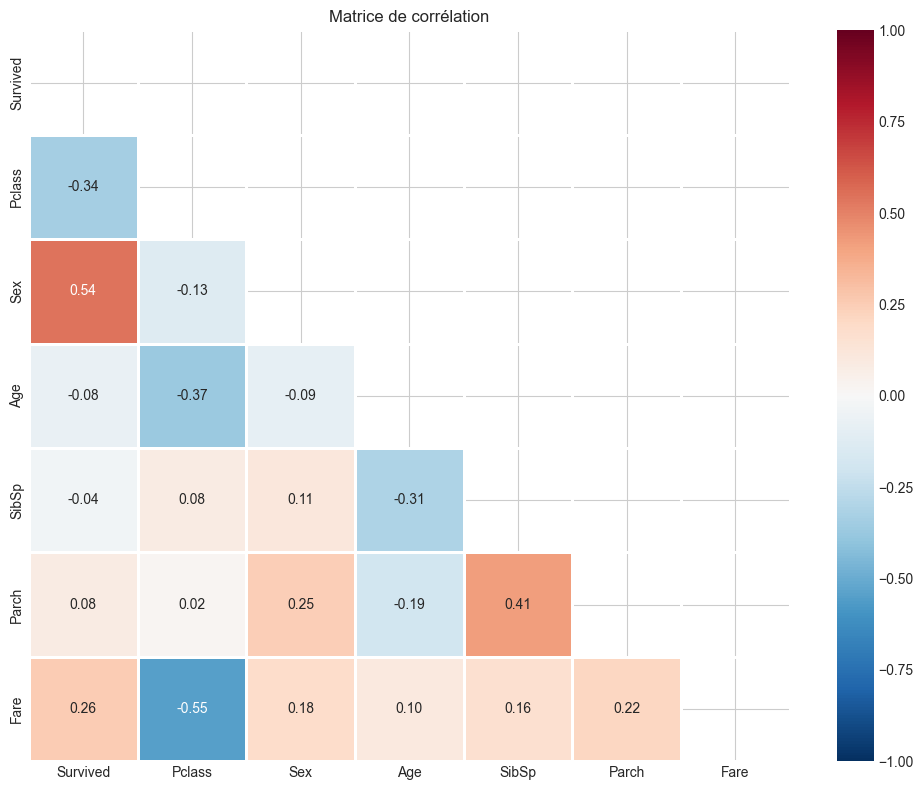

In [144]:
# Préparer les données pour la corrélation
df_corr = df.copy()
df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})

# Sélectionner les colonnes numériques
numeric_cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = df_corr[numeric_cols].corr()

# Créer le heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation')

# Sauvegarder et afficher
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()

In [145]:
# Corrélations avec la survie (triées)
correlations_with_survived = correlation_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False)

# Afficher les corrélations
print("Corrélations avec Survived :")
print("="*40)
for feature, corr in correlations_with_survived.items():
    direction = "↑" if corr > 0 else "↓"
    strength = "forte" if abs(corr) > 0.3 else "modérée" if abs(corr) > 0.15 else "faible"
    print(f"{feature:12} : {corr:+.3f} {direction} ({strength})")

Corrélations avec Survived :
Sex          : +0.543 ↑ (forte)
Pclass       : -0.338 ↓ (forte)
Fare         : +0.257 ↑ (modérée)
Parch        : +0.082 ↑ (faible)
Age          : -0.077 ↓ (faible)
SibSp        : -0.035 ↓ (faible)


**INSIGHTS sur les corrélations :**
1. **Sex** (0.54) : Corrélation forte positive (femme = survie)
2. **Pclass** (-0.34) : Corrélation modérée négative (classe basse = moins de survie)
3. **Fare** (0.26) : Corrélation modérée positive (prix élevé = survie)
4. **Parch** (0.08) : Corrélation faible

---
## 5. Analyse des outliers

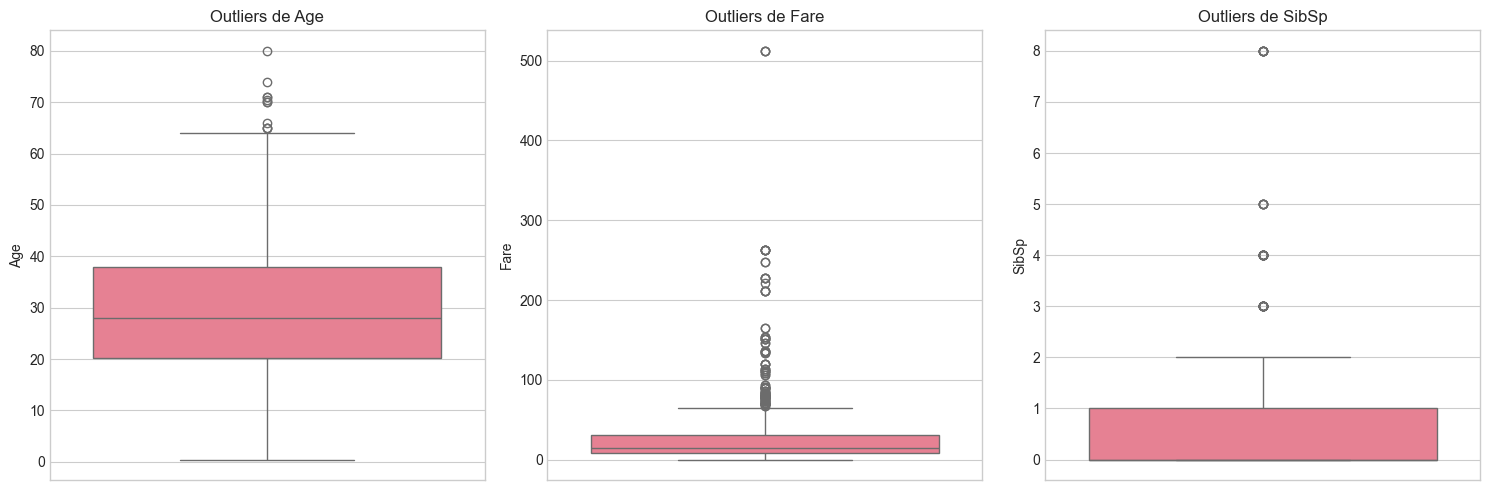

Nombre d'outliers pour Fare : 116 (13.0%)
Valeur max de Fare : $512.33


In [146]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplots pour Age, Fare et SibSp
for i, col in enumerate(['Age', 'Fare', 'SibSp']):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'Outliers de {col}')

plt.tight_layout()
plt.savefig('../reports/figures/outliers_analysis.png', dpi=150)
plt.show()

# Identifier les outliers de Fare
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
outliers_fare = df[(df['Fare'] < Q1 - 1.5*IQR) | (df['Fare'] > Q3 + 1.5*IQR)]

# Afficher les outliers
print(f"Nombre d'outliers pour Fare : {len(outliers_fare)} ({len(outliers_fare)/len(df)*100:.1f}%)")
print(f"Valeur max de Fare : ${df['Fare'].max():.2f}")

---
## 6. Résumé des insights

### Variables les plus importantes :
1. **Sex** - Variable la plus prédictive (femmes survivent plus)
2. **Pclass** - La classe sociale impacte fortement la survie
3. **Age** - Les enfants ont plus de chances
4. **Fare** - Prix élevé = meilleure survie (lié à la classe)